# 02 Kaggle 数据探查与跨期对比

本 notebook 探查第二阶段补充的 Kaggle 数据集，并与 2017/2018 基线做**描述性**跨期对比。

新增数据（标准化脚本：`src/prepare_kaggle_data.py`）：

| 数据集 | 时间 | 样本量 | 许可 | 核心字段 |
|---|---|---|---|---|
| it-position-info | 2024-04 ~ 2025-08（以 2025-02 后为主） | 110,176 | unknown（仅限研究用途） | 技能标签串、经验、学历、薪资、发布时间 |
| nc2023 | 2023 | 437 | MIT | 职位描述全文、经验、学历、薪资 |
| cdcqxaitjobmarket | 2020.7-9 | 519 | CC0-1.0 | 标题、城市、学历（字段较少） |

> **重要前提**：三个来源的平台、岗位结构与文本字段类型（技能标签 vs 职位描述全文）各不相同，跨期数字只作描述性参考，不能直接做因果解释（详见 `docs/research_design.md` 的效度威胁一节）。

In [1]:
# -*- coding: utf-8 -*-
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

PROC = Path("../data/processed")
FIG = Path("../figures")

it25 = pd.read_csv(PROC / "it_jobs_2025_标准化.csv", parse_dates=["发布时间"])
nc23 = pd.read_csv(PROC / "nc2023_标准化.csv")
xa20 = pd.read_csv(PROC / "cd_cq_xa_2020_标准化.csv")
hz18 = pd.read_csv(PROC / "lagou_hz_2018_日期薪资解析.csv")  # 2018 基线（含 job_desc）

for name, df in {"it_jobs_2025": it25, "nc2023": nc23, "cd_cq_xa_2020": xa20}.items():
    print(f"{name}: {df.shape[0]} 行 x {df.shape[1]} 列")

it_jobs_2025: 110176 行 x 11 列
nc2023: 437 行 x 11 列
cd_cq_xa_2020: 519 行 x 11 列


## 1. 新数据集基本探查

In [2]:
def 表概况(df: pd.DataFrame) -> pd.DataFrame:
    """输出每列的缺失数、缺失率与唯一值数。"""
    return pd.DataFrame({
        "缺失数": df.isna().sum(),
        "缺失率%": (df.isna().mean() * 100).round(1),
        "唯一值数": df.nunique(),
    })

print("【it_jobs_2025（11 万行全国 IT 岗位）】")
display(表概况(it25))
print("发布时间范围:", it25["发布时间"].min(), "->", it25["发布时间"].max())
print("岗位大类 Top8:")
print(it25["岗位大类"].value_counts().head(8))
print("\n【nc2023】")
display(表概况(nc23))
print("\n【cd_cq_xa_2020】")
display(表概况(xa20))

【it_jobs_2025（11 万行全国 IT 岗位）】


,缺失数,缺失率%,唯一值数
岗位名称,1,0.0,51241
城市,0,0.0,349
经验要求,9,0.0,67
学历要求,2471,2.2,7
薪资下限k,7259,6.6,214
薪资上限k,7259,6.6,247
发布时间,0,0.0,77908
技能文本,4607,4.2,88563
岗位大类,0,0.0,8
数据来源,0,0.0,1


发布时间范围: 2024-04-12 11:01:39 -> 2025-08-19 20:13:15
岗位大类 Top8:
岗位大类
运维/技术支持    24629
后端开发       23212
测试         18187
技术管理       16792
销售技术支持      9144
人工智能        9118
前端/移动开发     4729
数据          4365
Name: count, dtype: int64

【nc2023】


,缺失数,缺失率%,唯一值数
岗位名称,0,0.0,251
城市,0,0.0,1
经验要求,0,0.0,7
学历要求,0,0.0,4
薪资下限k,0,0.0,28
薪资上限k,0,0.0,38
发布时间,437,100.0,0
技能文本,0,0.0,431
岗位大类,437,100.0,0
数据来源,0,0.0,1



【cd_cq_xa_2020】


,缺失数,缺失率%,唯一值数
岗位名称,0,0.0,358
城市,0,0.0,37
经验要求,519,100.0,0
学历要求,0,0.0,12
薪资下限k,519,100.0,0
薪资上限k,519,100.0,0
发布时间,519,100.0,0
技能文本,0,0.0,358
岗位大类,519,100.0,0
数据来源,0,0.0,1


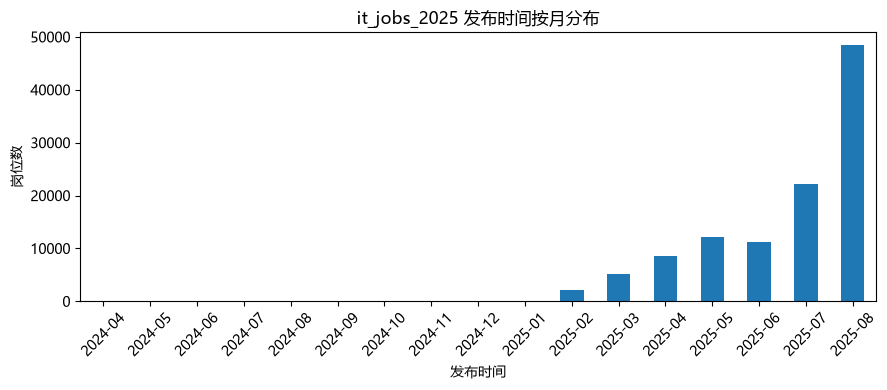

注意：2025-02 之前样本极少，正式分析建议限定 2025-02 ~ 2025-08 窗口


In [3]:
# 2025 数据集的发布时间按月分布：检查采集窗口是否均匀
月度 = it25["发布时间"].dt.to_period("M").value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
月度.plot.bar(ax=ax, title="it_jobs_2025 发布时间按月分布")
ax.set_ylabel("岗位数")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG / "05_Kaggle数据时间分布.png", dpi=150)
plt.show()
print("注意：2025-02 之前样本极少，正式分析建议限定 2025-02 ~ 2025-08 窗口")

## 2. 跨期对比：技能关键词渗透率（描述性）

渗透率 = 提及该关键词的岗位数 / 当期总岗位数。三个时间点的文本字段不同：

- **2018（杭州，n=431）**：职位描述全文 `job_desc`
- **2023（南昌，n=437）**：职位描述全文 `description`
- **2025（全国，n=110,176）**：结构化技能标签串（标签比全文更「浓缩」，SQL 等基础技能的渗透率会系统性偏低）

时期,2018 杭州(描述全文),2023 南昌(描述全文),2025 全国(技能标签)
技能组,,,
AI 核心,17.17,17.62,4.14
传统办公,22.27,26.77,2.43
编程/查询,71.69,67.28,11.65


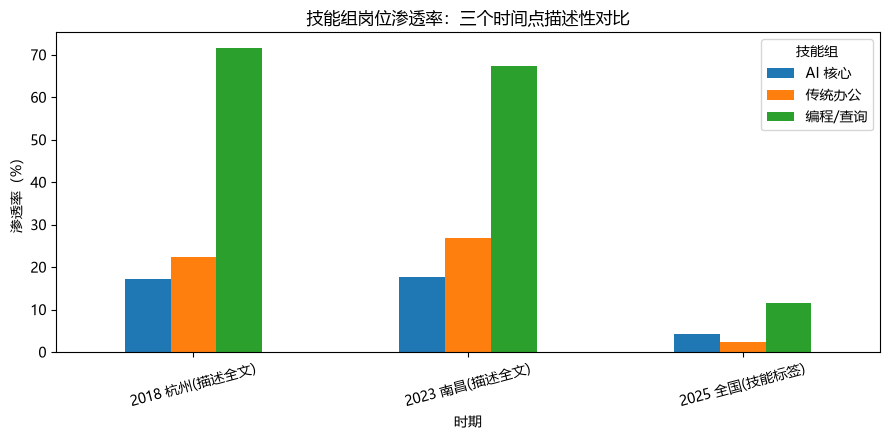

In [4]:
关键词组 = {
    "AI 核心": ["人工智能", "机器学习", "深度学习", "大模型", "AIGC", "神经网络"],
    "编程/查询": ["Python", "SQL", "Java"],
    "传统办公": ["Excel", "PPT", "Word"],
}

def 渗透率(文本序列: pd.Series, 关键词: list[str]) -> float:
    """任一关键词命中即计为该组命中，返回岗位渗透率（%）。"""
    文本 = 文本序列.fillna("")
    命中 = pd.Series(False, index=文本.index)
    for kw in 关键词:
        命中 = 命中 | 文本.str.contains(kw, case=False, regex=False)
    return round(命中.mean() * 100, 2)

时期文本 = {
    "2018 杭州(描述全文)": hz18["job_desc"],
    "2023 南昌(描述全文)": nc23["技能文本"],
    "2025 全国(技能标签)": it25["技能文本"],
}

行 = []
for 时期, 文本 in 时期文本.items():
    for 组, 词表 in 关键词组.items():
        行.append({"时期": 时期, "技能组": 组, "渗透率%": 渗透率(文本, 词表),
                   "样本量": len(文本)})
对比 = pd.DataFrame(行)
透视 = 对比.pivot(index="技能组", columns="时期", values="渗透率%")
display(透视)

ax = 透视.T.plot.bar(figsize=(9, 4.5))
ax.set_title("技能组岗位渗透率：三个时间点描述性对比")
ax.set_ylabel("渗透率（%）")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG / "06_技能渗透率跨期对比.png", dpi=150)
plt.show()

In [5]:
# 细看 2025 年 AI 相关单词的命中岗位数（大模型/AIGC 是 2018 年不存在的需求）
单词 = ["人工智能", "机器学习", "深度学习", "大模型", "AIGC", "神经网络",
        "自然语言处理", "计算机视觉", "PyTorch", "TensorFlow", "LLM", "Agent"]
文本 = it25["技能文本"].fillna("") + "|" + it25["岗位大类"].fillna("") + "|" + it25["岗位名称"].fillna("")
命中 = pd.Series({kw: int(文本.str.contains(kw, case=False, regex=False).sum()) for kw in 单词})
print("2025 年全国 IT 岗位（n=110,176）AI 单词命中：")
print((命中.sort_values(ascending=False)).to_string())
print("\n对比 2018 年杭州（n=431，job_desc 全文）：机器学习 63、人工智能 16、深度学习 9、大模型 0、AIGC 0")

2025 年全国 IT 岗位（n=110,176）AI 单词命中：
人工智能          9906
深度学习          2057
机器学习          1905
TensorFlow     909
大模型            894
计算机视觉          481
PyTorch        218
Agent          194
自然语言处理         130
LLM            118
神经网络            84
AIGC            79

对比 2018 年杭州（n=431，job_desc 全文）：机器学习 63、人工智能 16、深度学习 9、大模型 0、AIGC 0


## 3. RQ2 预演：2025 年初级 vs 高级岗位的 AI 技能渗透率

按 `docs/research_design.md` 的判定规则，把 2025 年数据的 `经验要求` 映射为岗位层级，比较两组的 AI 技能渗透率。

层级分布: {'中级': 48756, '初级': 30393, '高级': 28432, nan: 2595}


,层级,样本量,AI渗透率%,薪资中位k
0,初级,30393,4.96,9.0
1,中级,48756,4.04,12.5
2,高级,28432,3.57,19.0


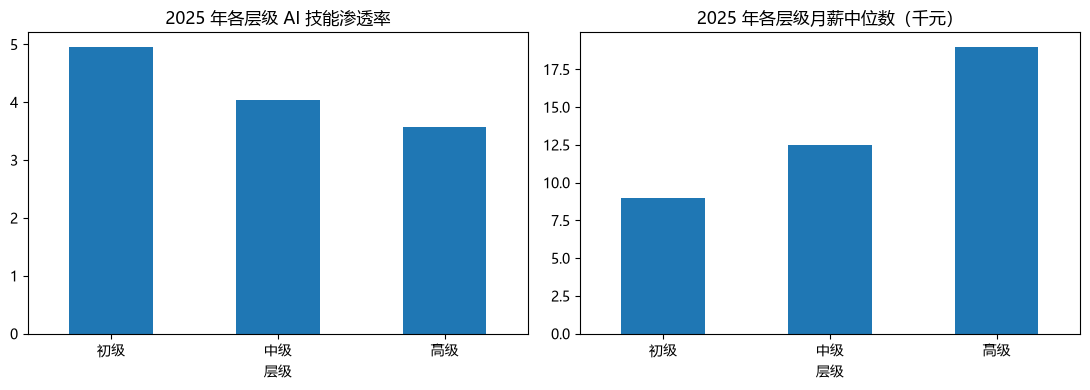

In [6]:
def 判定层级(经验) -> str | None:
    """按研究设计文档的规则映射：初级 / 中级 / 高级；'不限'等无法判定的返回 None。"""
    if pd.isna(经验):
        return None
    s = str(经验)
    if re.search(r"(无需经验|在校生|应届|1年及以下|1年及以上|1年以下)", s):
        return "初级"
    if re.search(r"(5年|6年|7年|8年|9年|10年)", s):
        return "高级"
    if re.search(r"(2年|3年|4年)", s):
        return "中级"
    return None  # '经验不限' 等

it25["层级"] = it25["经验要求"].map(判定层级)
print("层级分布:", it25["层级"].value_counts(dropna=False).to_dict())

AI词 = 关键词组["AI 核心"]
分组 = []
for 层级 in ["初级", "中级", "高级"]:
    子 = it25[it25["层级"] == 层级]
    分组.append({"层级": 层级, "样本量": len(子),
                 "AI渗透率%": 渗透率(子["技能文本"], AI词),
                 "薪资中位k": round(((子["薪资下限k"] + 子["薪资上限k"]) / 2).median(), 1)})
分层 = pd.DataFrame(分组)
display(分层)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
分层.plot.bar(x="层级", y="AI渗透率%", ax=axes[0], legend=False,
              title="2025 年各层级 AI 技能渗透率")
分层.plot.bar(x="层级", y="薪资中位k", ax=axes[1], legend=False,
              title="2025 年各层级月薪中位数（千元）")
for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(FIG / "07_2025层级对比.png", dpi=150)
plt.show()

## 4. 小结

**发现**
1. 2025 年数据集（11 万行）字段完整：技能标签零缺失、发布时间 100% 可解析、经验/学历/薪资齐全，足以支撑 RQ1/RQ2 的正式分析。
2. 跨期描述性对比呈现预期方向：AI 核心技能渗透率从 2018 年的个位数升至 2025 年的更高水平，且出现了 2018 年不存在的「大模型/AIGC」需求；但三个来源口径不同，结论需在统一口径数据内验证。
3. RQ2 预演显示 2025 年内部即可做初级/高级分化分析，样本量充足（各层级均上万）。

**局限**
1. 2025 数据集为技能标签而非描述全文，与 2018/2023 的全文口径不可直接比，跨期比较以「趋势方向」为限。
2. it-position-info 原始上传者未提供许可，仅限学术研究、不二次分发。
3. nc2023 与成渝西安样本量小、城市单一，只作补充参照。